# [LAB-06] 14-2 Pair Plot

## #01. 준비작업

### 1. 라이브러리 참조

In [1]:
from jussam import load_data
from helpers import my_plot
import seaborn as sb

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터 가져오기

In [2]:
origin = load_data('penguins')
origin

📚 남극 팔머 군도의 펭귄 3종에 대해 신체 치수와 서식지 정보(출처: https://www.kaggle.com/datasets/larsen0966/penguins)

    field              description
--  -----------------  -------------
 0  species            팽귄 종
 1  island             서식지
 2  bill_length_mm     부리 길이
 3  bill_depth_mm      부리 두께
 4  flipper_length_mm  날개 길이
 5  body_mass_g        몸무게
 6  sex                성별



,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.100,18.700,181,3750,MALE
1,Adelie,Torgersen,39.500,17.400,186,3800,FEMALE
2,Adelie,Torgersen,40.300,18.000,195,3250,FEMALE
3,Adelie,Torgersen,36.700,19.300,193,3450,FEMALE
4,Adelie,Torgersen,39.300,20.600,190,3650,MALE
...,...,...,...,...,...,...,...
329,Gentoo,Biscoe,47.200,13.700,214,4925,FEMALE
330,Gentoo,Biscoe,46.800,14.300,215,4850,FEMALE
331,Gentoo,Biscoe,50.400,15.700,222,5750,MALE
332,Gentoo,Biscoe,45.200,14.800,212,5200,FEMALE


## #02. PairPlot 시각화

### 1. 기본형

- 자동으로 연속형 데이터만 처리한다.

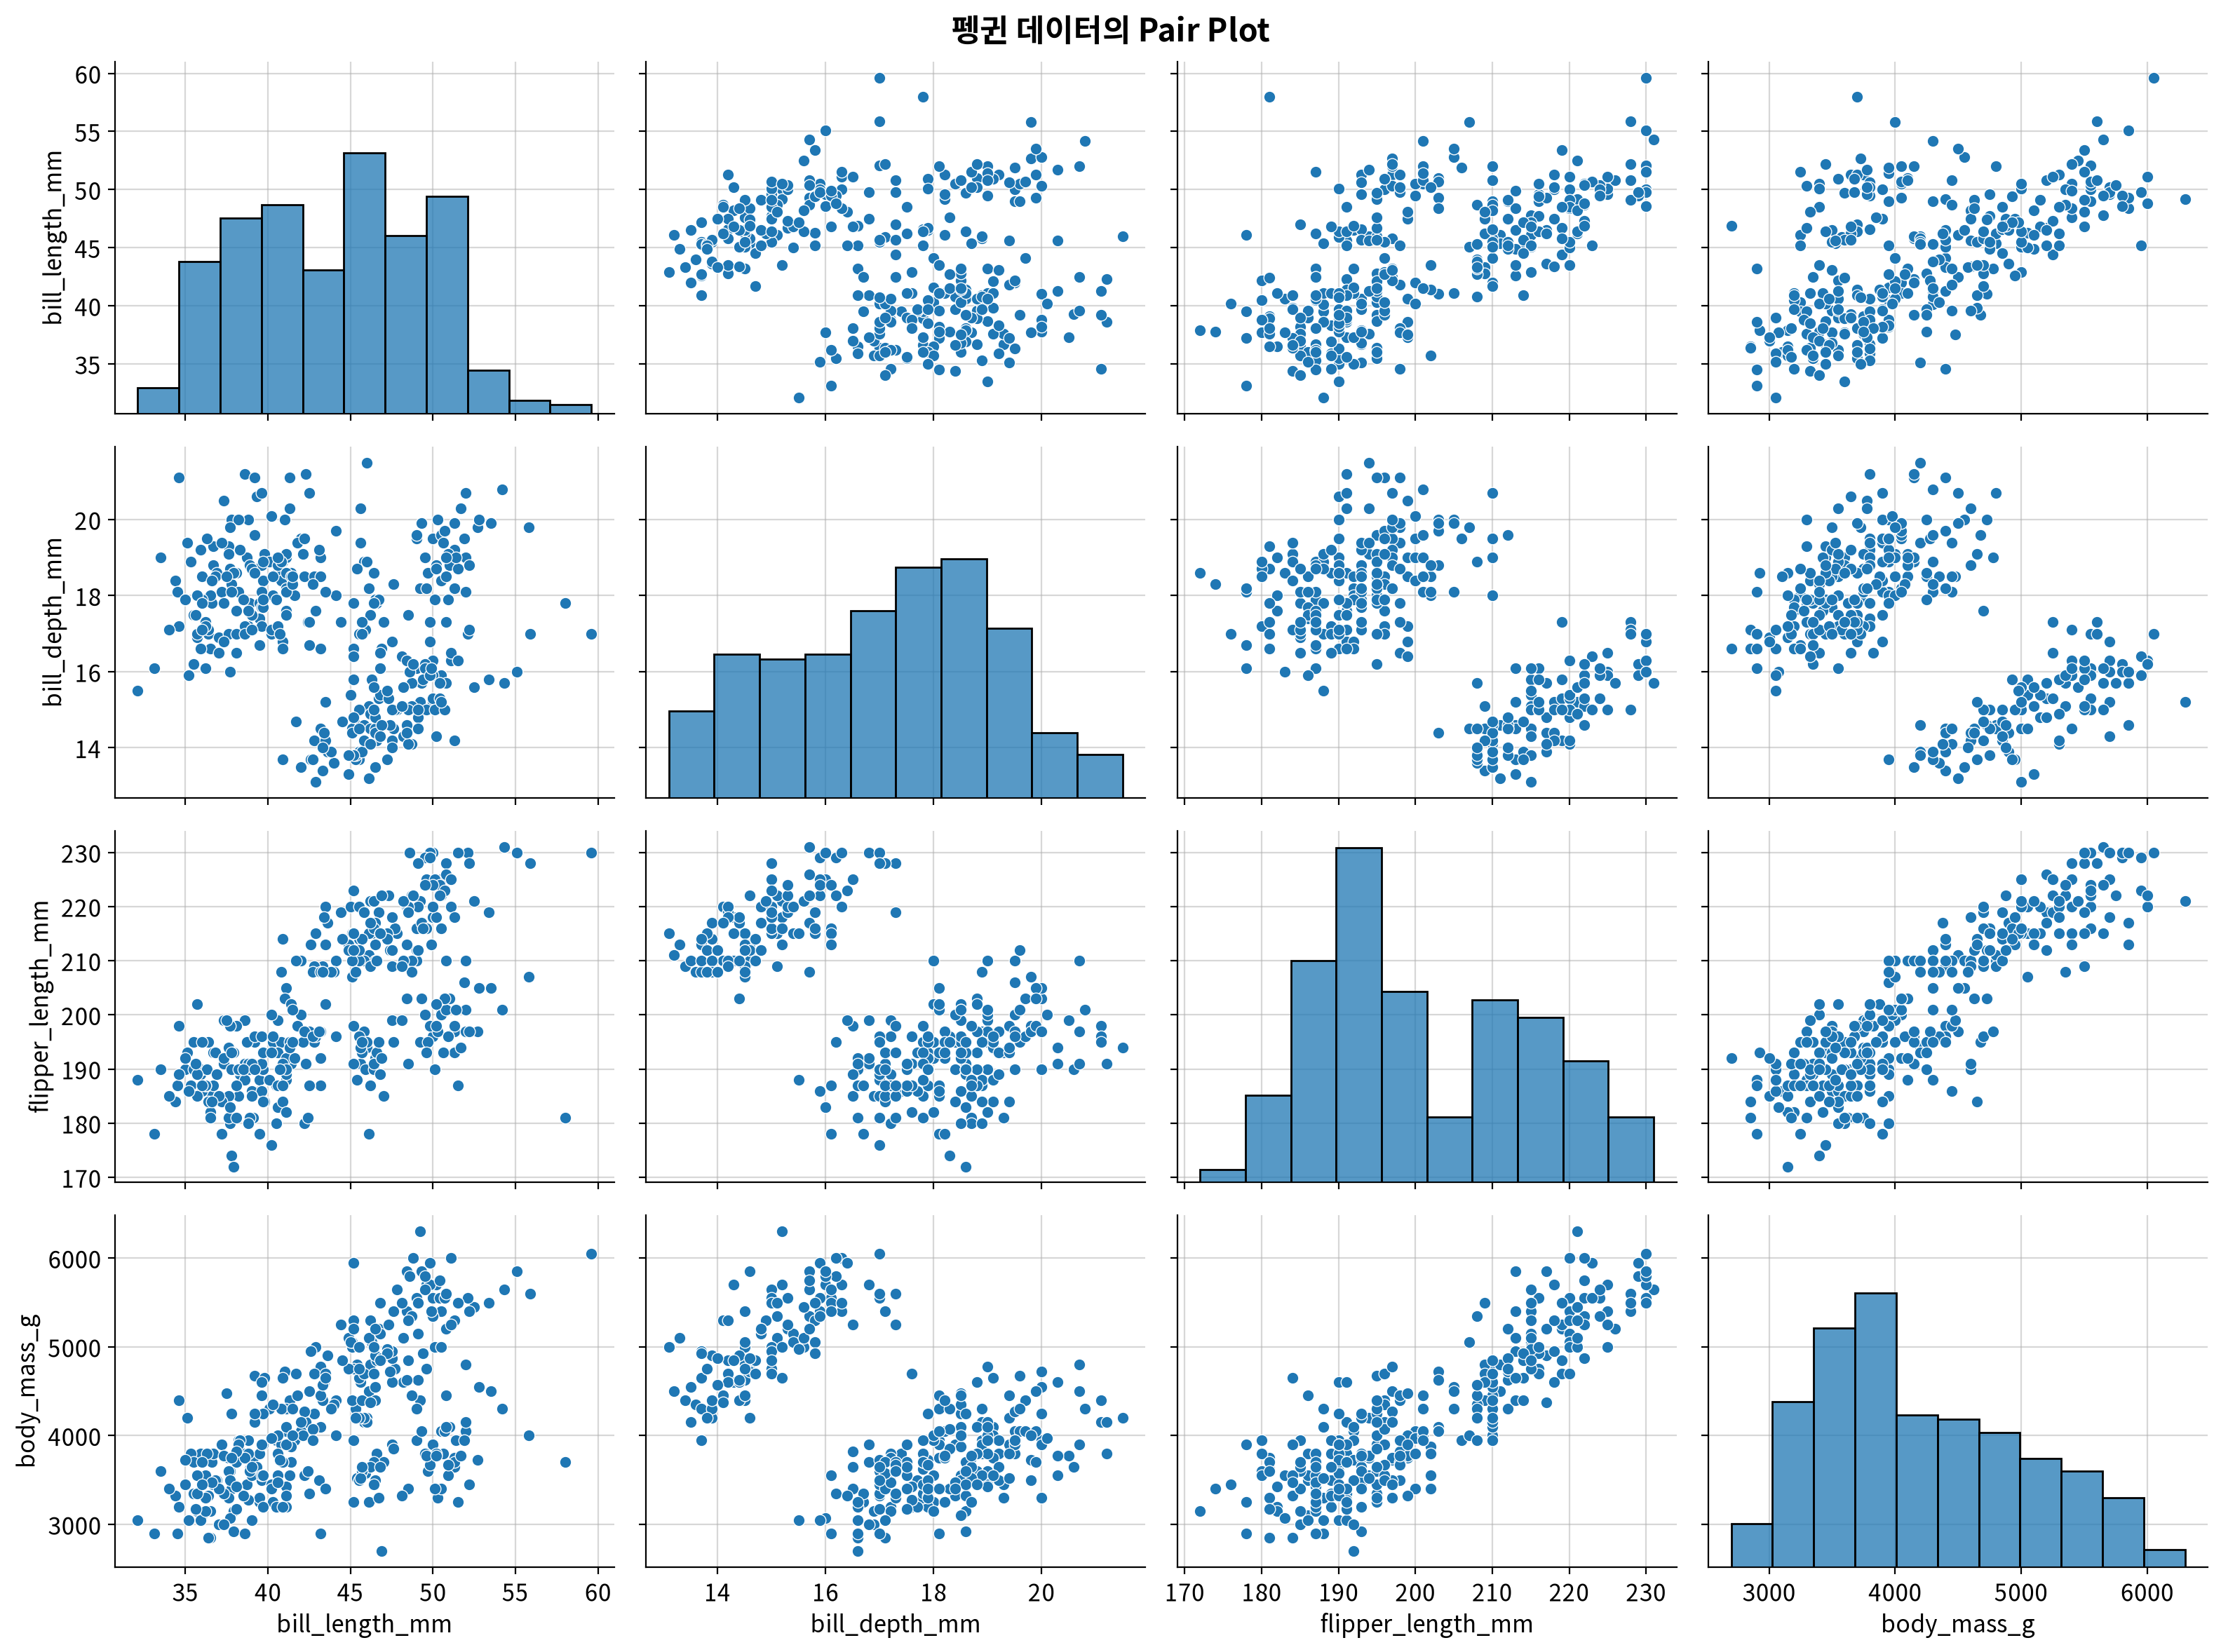

In [3]:
# 1) 그래프 초기화
width  = 1600       # 그래프 가로 px 크기
height = 1200       # 그래프 세로 px 크기
my_dpi = 200        # 그래프 해상도 (DPI)

# 그래프 크기를 inch 단위로 변환
figsize = (width / 100, height / 100)

# 2) Pait Plot 그리기
g = sb.pairplot(origin)
g.fig.set_dpi(my_dpi)
g.fig.set_figwidth(figsize[0])
g.fig.set_figheight(figsize[1])

# 제목 추가
g.fig.suptitle("펭귄 데이터의 Pair Plot", fontsize=16, fontweight="bold")

# 3) 개별 그래프 설정
for ax in g.axes.flatten():
    # 격자를 그래프 뒤로 이동
    ax.set_axisbelow(True)
    # 격자 추가
    ax.grid(True, alpha=0.5)

# 4) 출력
my_plot.show()

#### 💡 인사이트

- **강한 양의 상관관계**: 
  - 부리 길이, 지느러미 길이, 체중 간 강한 양의 상관관계 관찰     
    → 이 세 변수는 펭귄의 체형 크기를 함께 나타내는 지표임
- **부리 깊이의 약한 상관관계**: 
  - 부리 깊이는 다른 변수들과 약한 상관관계     
    → 체형 크기와 독립적인 특성
- **정규분포 근사**: 
  - 대각선 히스토그램에서 모든 변수가 대체로 정규분포에 가까운 형태     
    → 통계 분석에 유리한 데이터 특성
- **일부 이상치 존재**: 
  - 특히 부리 길이와 체중에서 우측 상단에 떨어진 점들     
    → 특이한 특성을 가진 개체 존재

### 2. 범주별 구분 및 마커 모양 설정

- `hue` 파라미터에 변수를 할당하면 hue 의미론적 매핑이 추가되고     
  기본 주변 플롯이 계층화된 커널 밀도 추정(KDE)으로 변경된다.

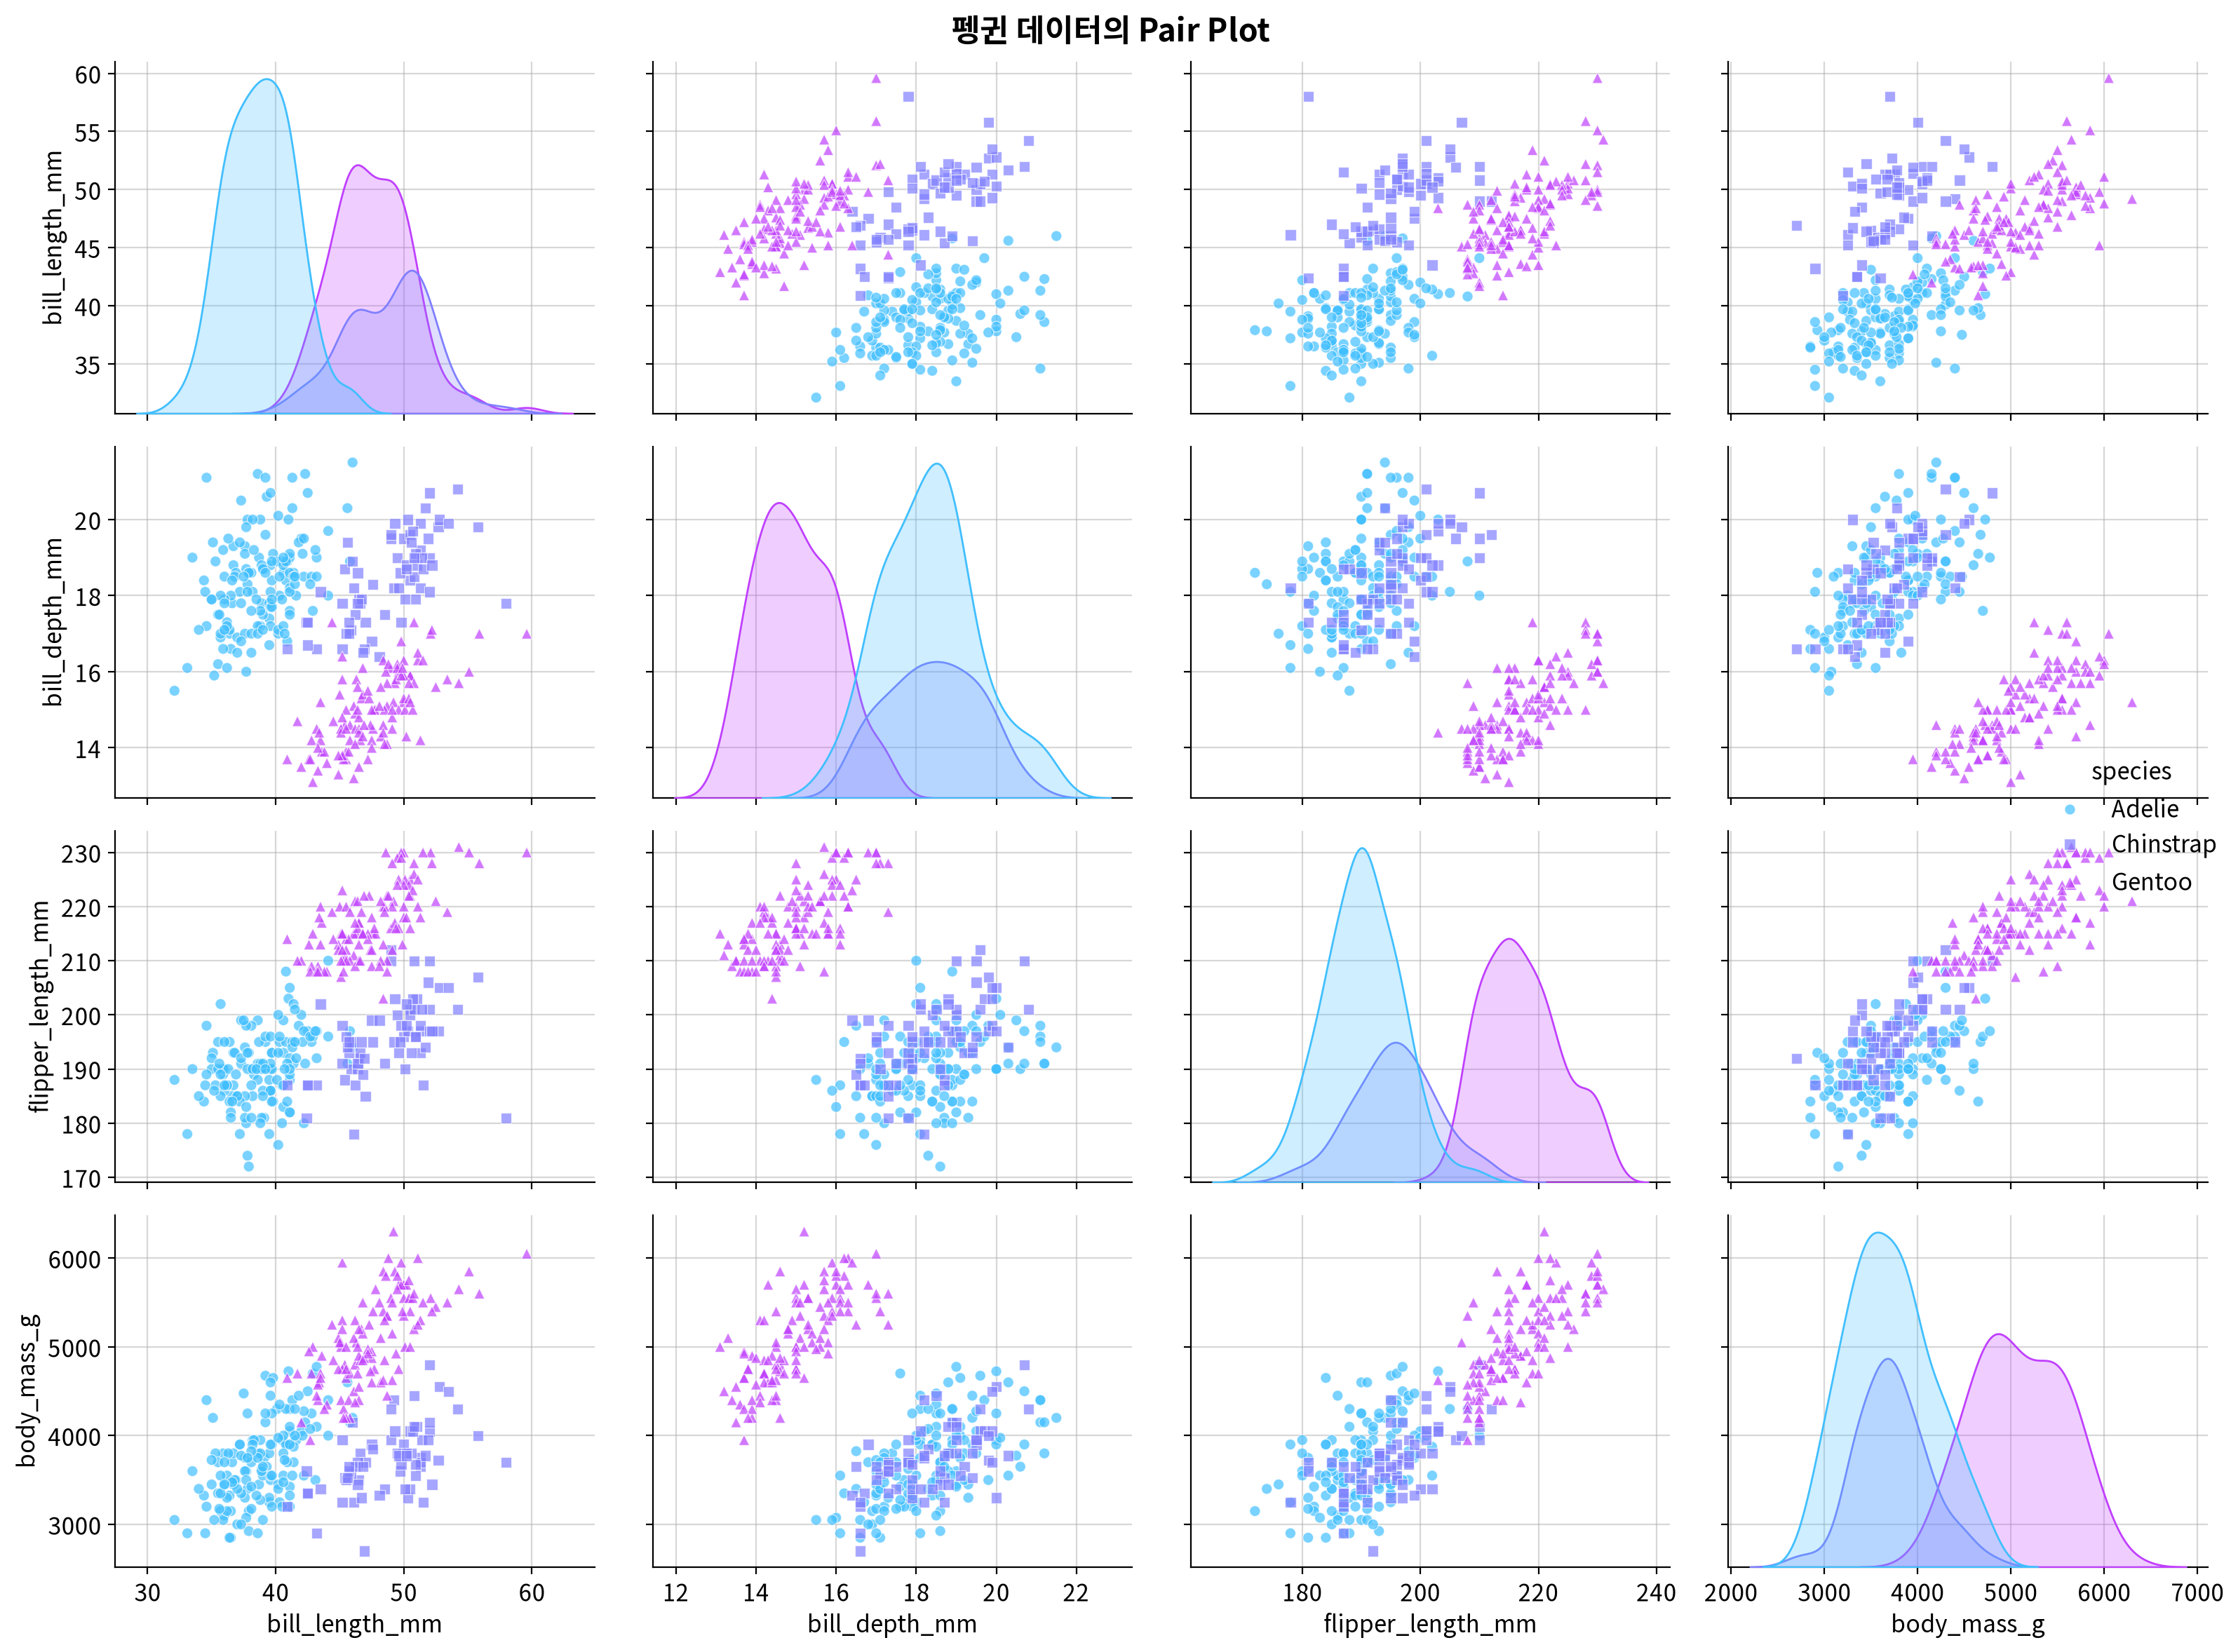

In [4]:
# 1) 그래프 초기화
width  = 1600       # 그래프 가로 px 크기
height = 1200       # 그래프 세로 px 크기
my_dpi = 200        # 그래프 해상도 (DPI)

# 그래프 크기를 inch 단위로 변환
figsize = (width / 100, height / 100)

# 2) Pait Plot 그리기 --> 종별로 구분하도록 `hue` 파라미터 추가
g = sb.pairplot(origin, 
                hue='species',              # 범주형 컬럼명 지정
                markers=['o', 's', '^'],    # 종별로 다른 마커 사용
                palette='cool',             # 종별로 다른 색상 팔레트 사용
                plot_kws={'s': 30, 'alpha': 0.7}    # 마커크기와 투명도
)
g.fig.set_dpi(my_dpi)
g.fig.set_figwidth(figsize[0])
g.fig.set_figheight(figsize[1])

# 제목 추가
g.fig.suptitle("펭귄 데이터의 Pair Plot", fontsize=16, fontweight="bold")

# 3) 개별 그래프 설정
for ax in g.axes.flatten():
    ax.set_axisbelow(True)  # 격자를 그래프 뒤로 이동
    ax.grid(True, alpha=0.5)  # 격자 추가

# 4) 출력
my_plot.show()

### 3. 추세선 적용

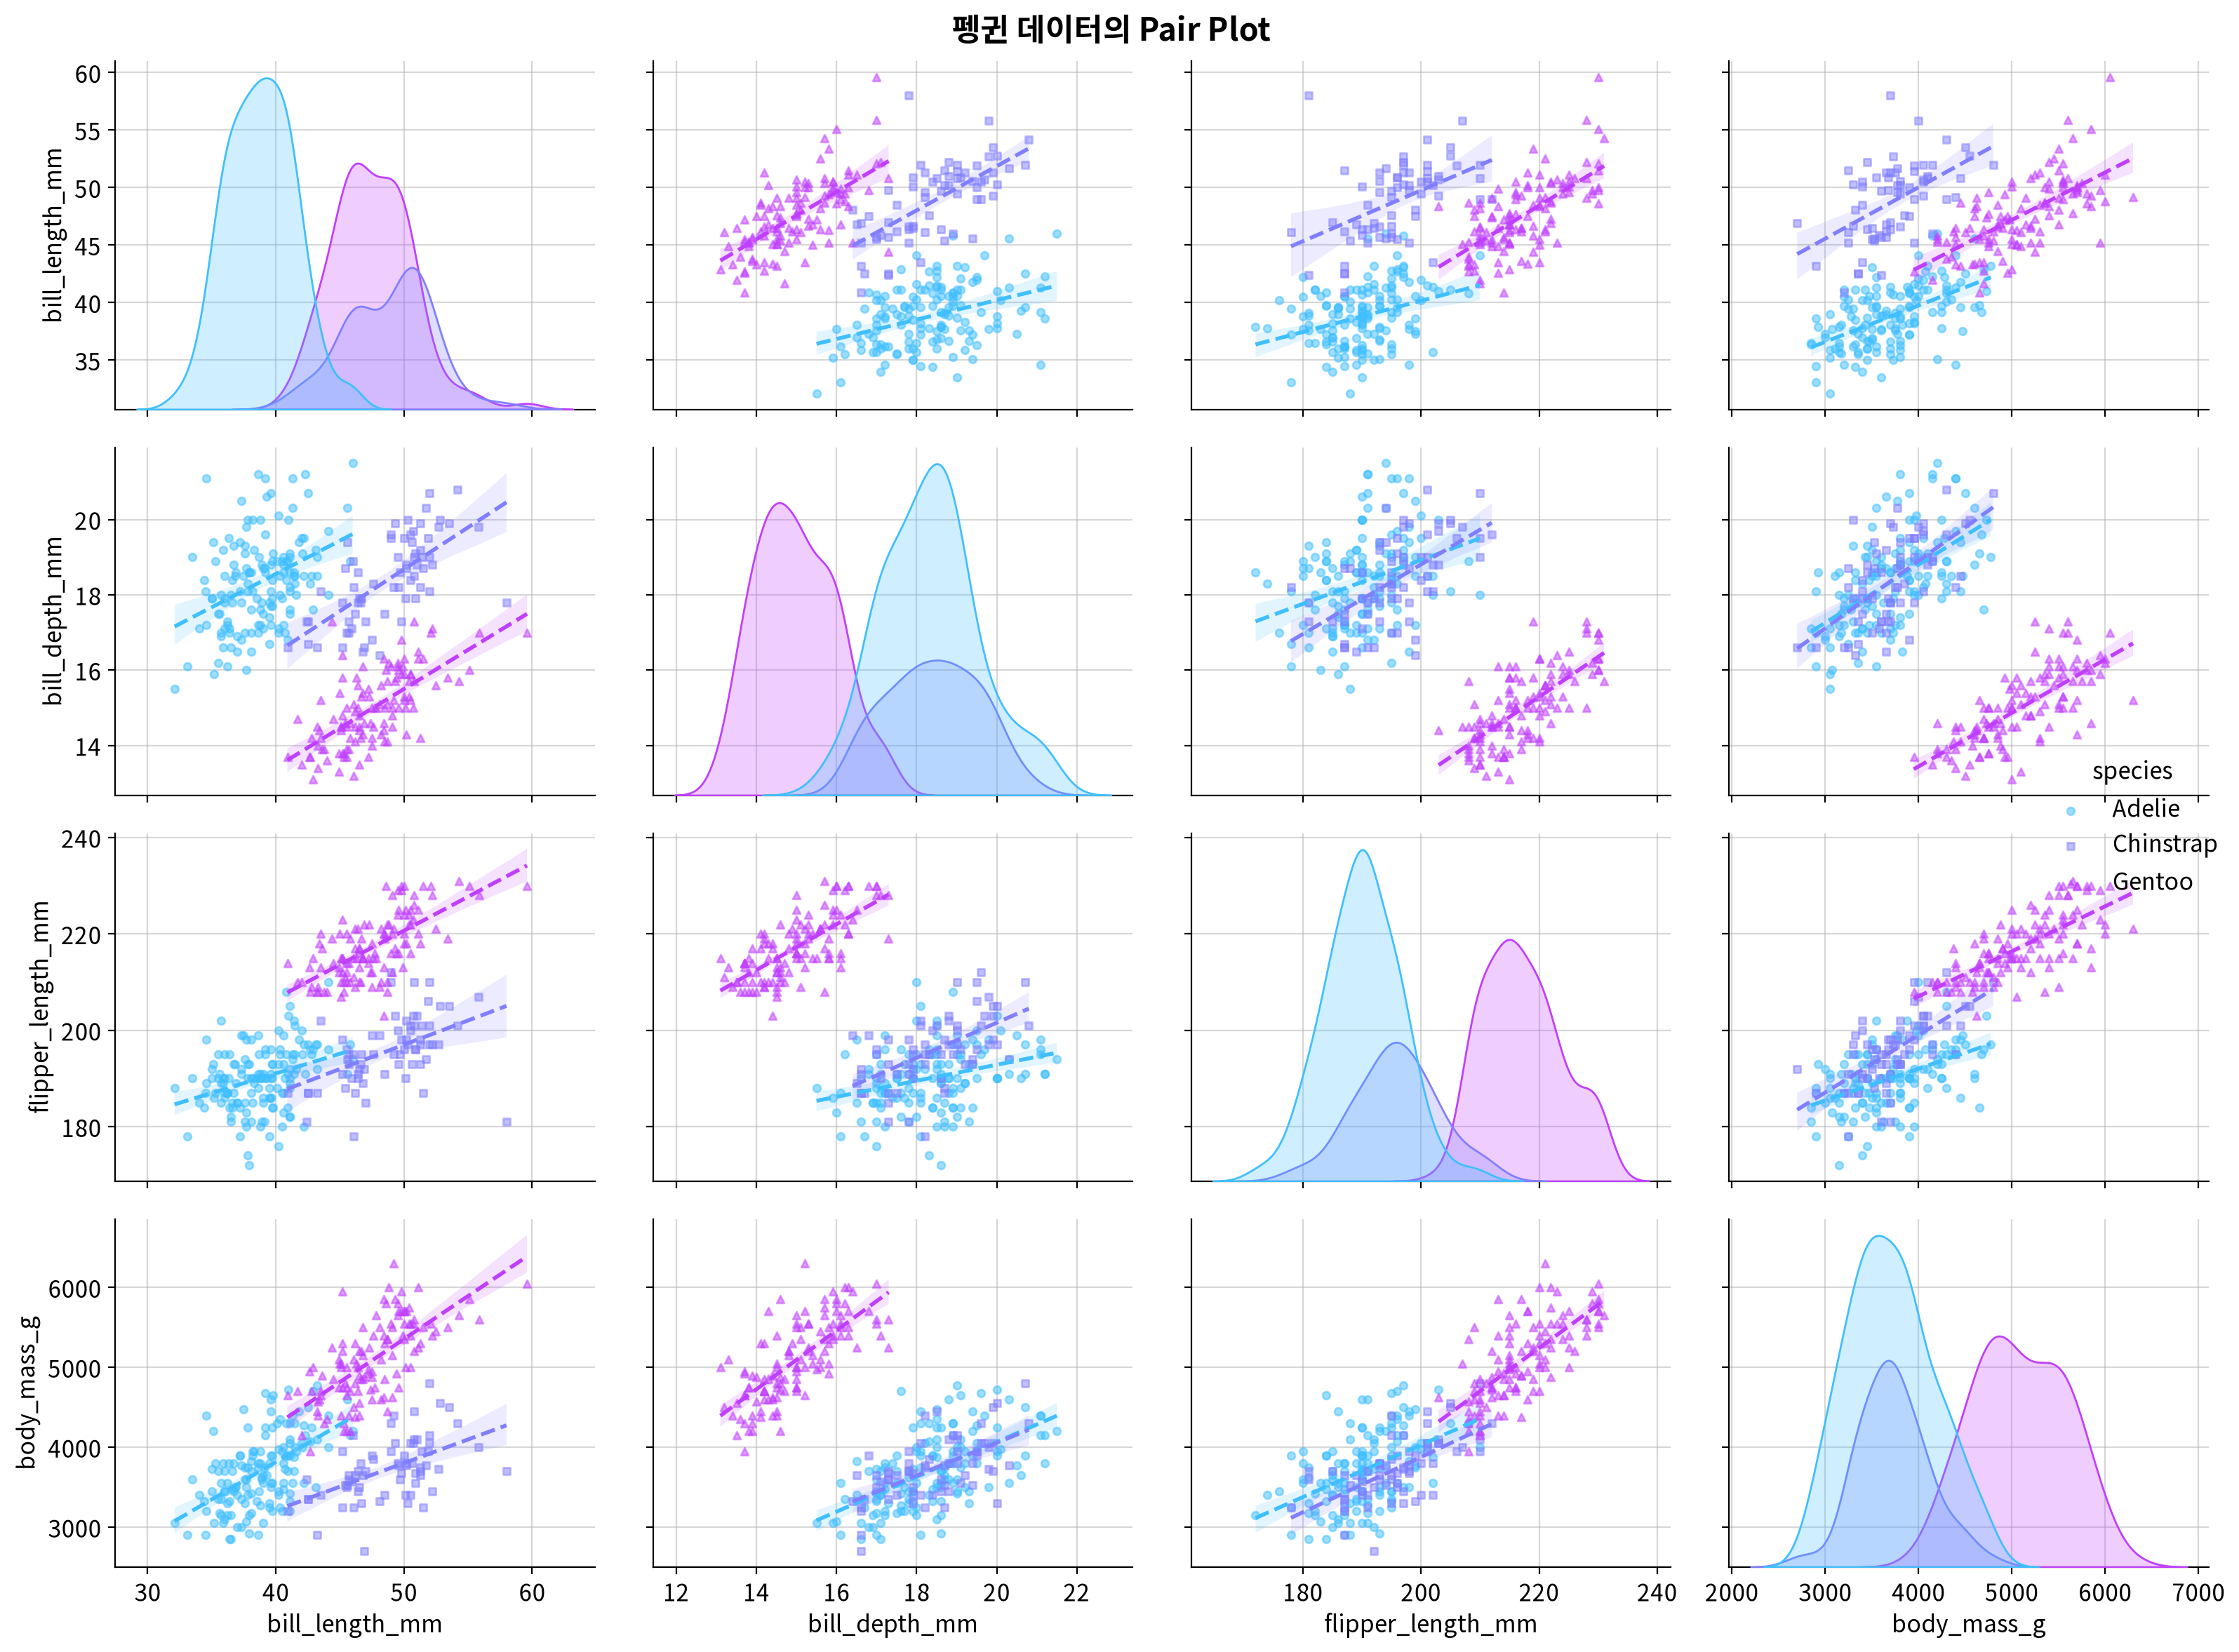

In [5]:
# 1) 그래프 초기화
width  = 1600       # 그래프 가로 px 크기
height = 1200       # 그래프 세로 px 크기
my_dpi = 200        # 그래프 해상도 (DPI)

# 그래프 크기를 inch 단위로 변환
figsize = (width / 100, height / 100)

# 2) Pait Plot 그리기 --> 종별로 구분하도록 `hue` 파라미터 추가
g = sb.pairplot(origin, 
                hue='species',              # 범주형 컬럼명 지정
                markers=['o', 's', '^'],    # 종별로 다른 마커 사용
                palette='cool',             # 종별로 다른 색상 팔레트 사용
                diag_kind='kde',  # 대각선에 KDE 플롯 사용(kde 대신 hist 가능)
                kind='reg',                 # 산점도에 회귀선 추가
                # 회귀선을 설정한 경우 모양 설정 방법이 세분화 됨
                plot_kws={
                    # 마커 설정
                    'scatter_kws': {'s': 15, 'alpha': 0.5},
                    # 회귀선 스타일
                    'line_kws': {'linewidth': 2, 'linestyle': '--'}
                },
)
g.fig.set_dpi(my_dpi)
g.fig.set_figwidth(figsize[0])
g.fig.set_figheight(figsize[1])

# 제목 추가
g.fig.suptitle("펭귄 데이터의 Pair Plot", fontsize=16, fontweight="bold")

# 3) 개별 그래프 설정
for ax in g.axes.flatten():
    ax.set_axisbelow(True)  # 격자를 그래프 뒤로 이동
    ax.grid(True, alpha=0.5)  # 격자 추가

# 4) 출력
my_plot.show()

### 4. 선택적 변수 적용

- `x_vars` 파라미터와 `y_vars` 파라미터에 원하는 변수를 리스트 타입으로 지정한다.

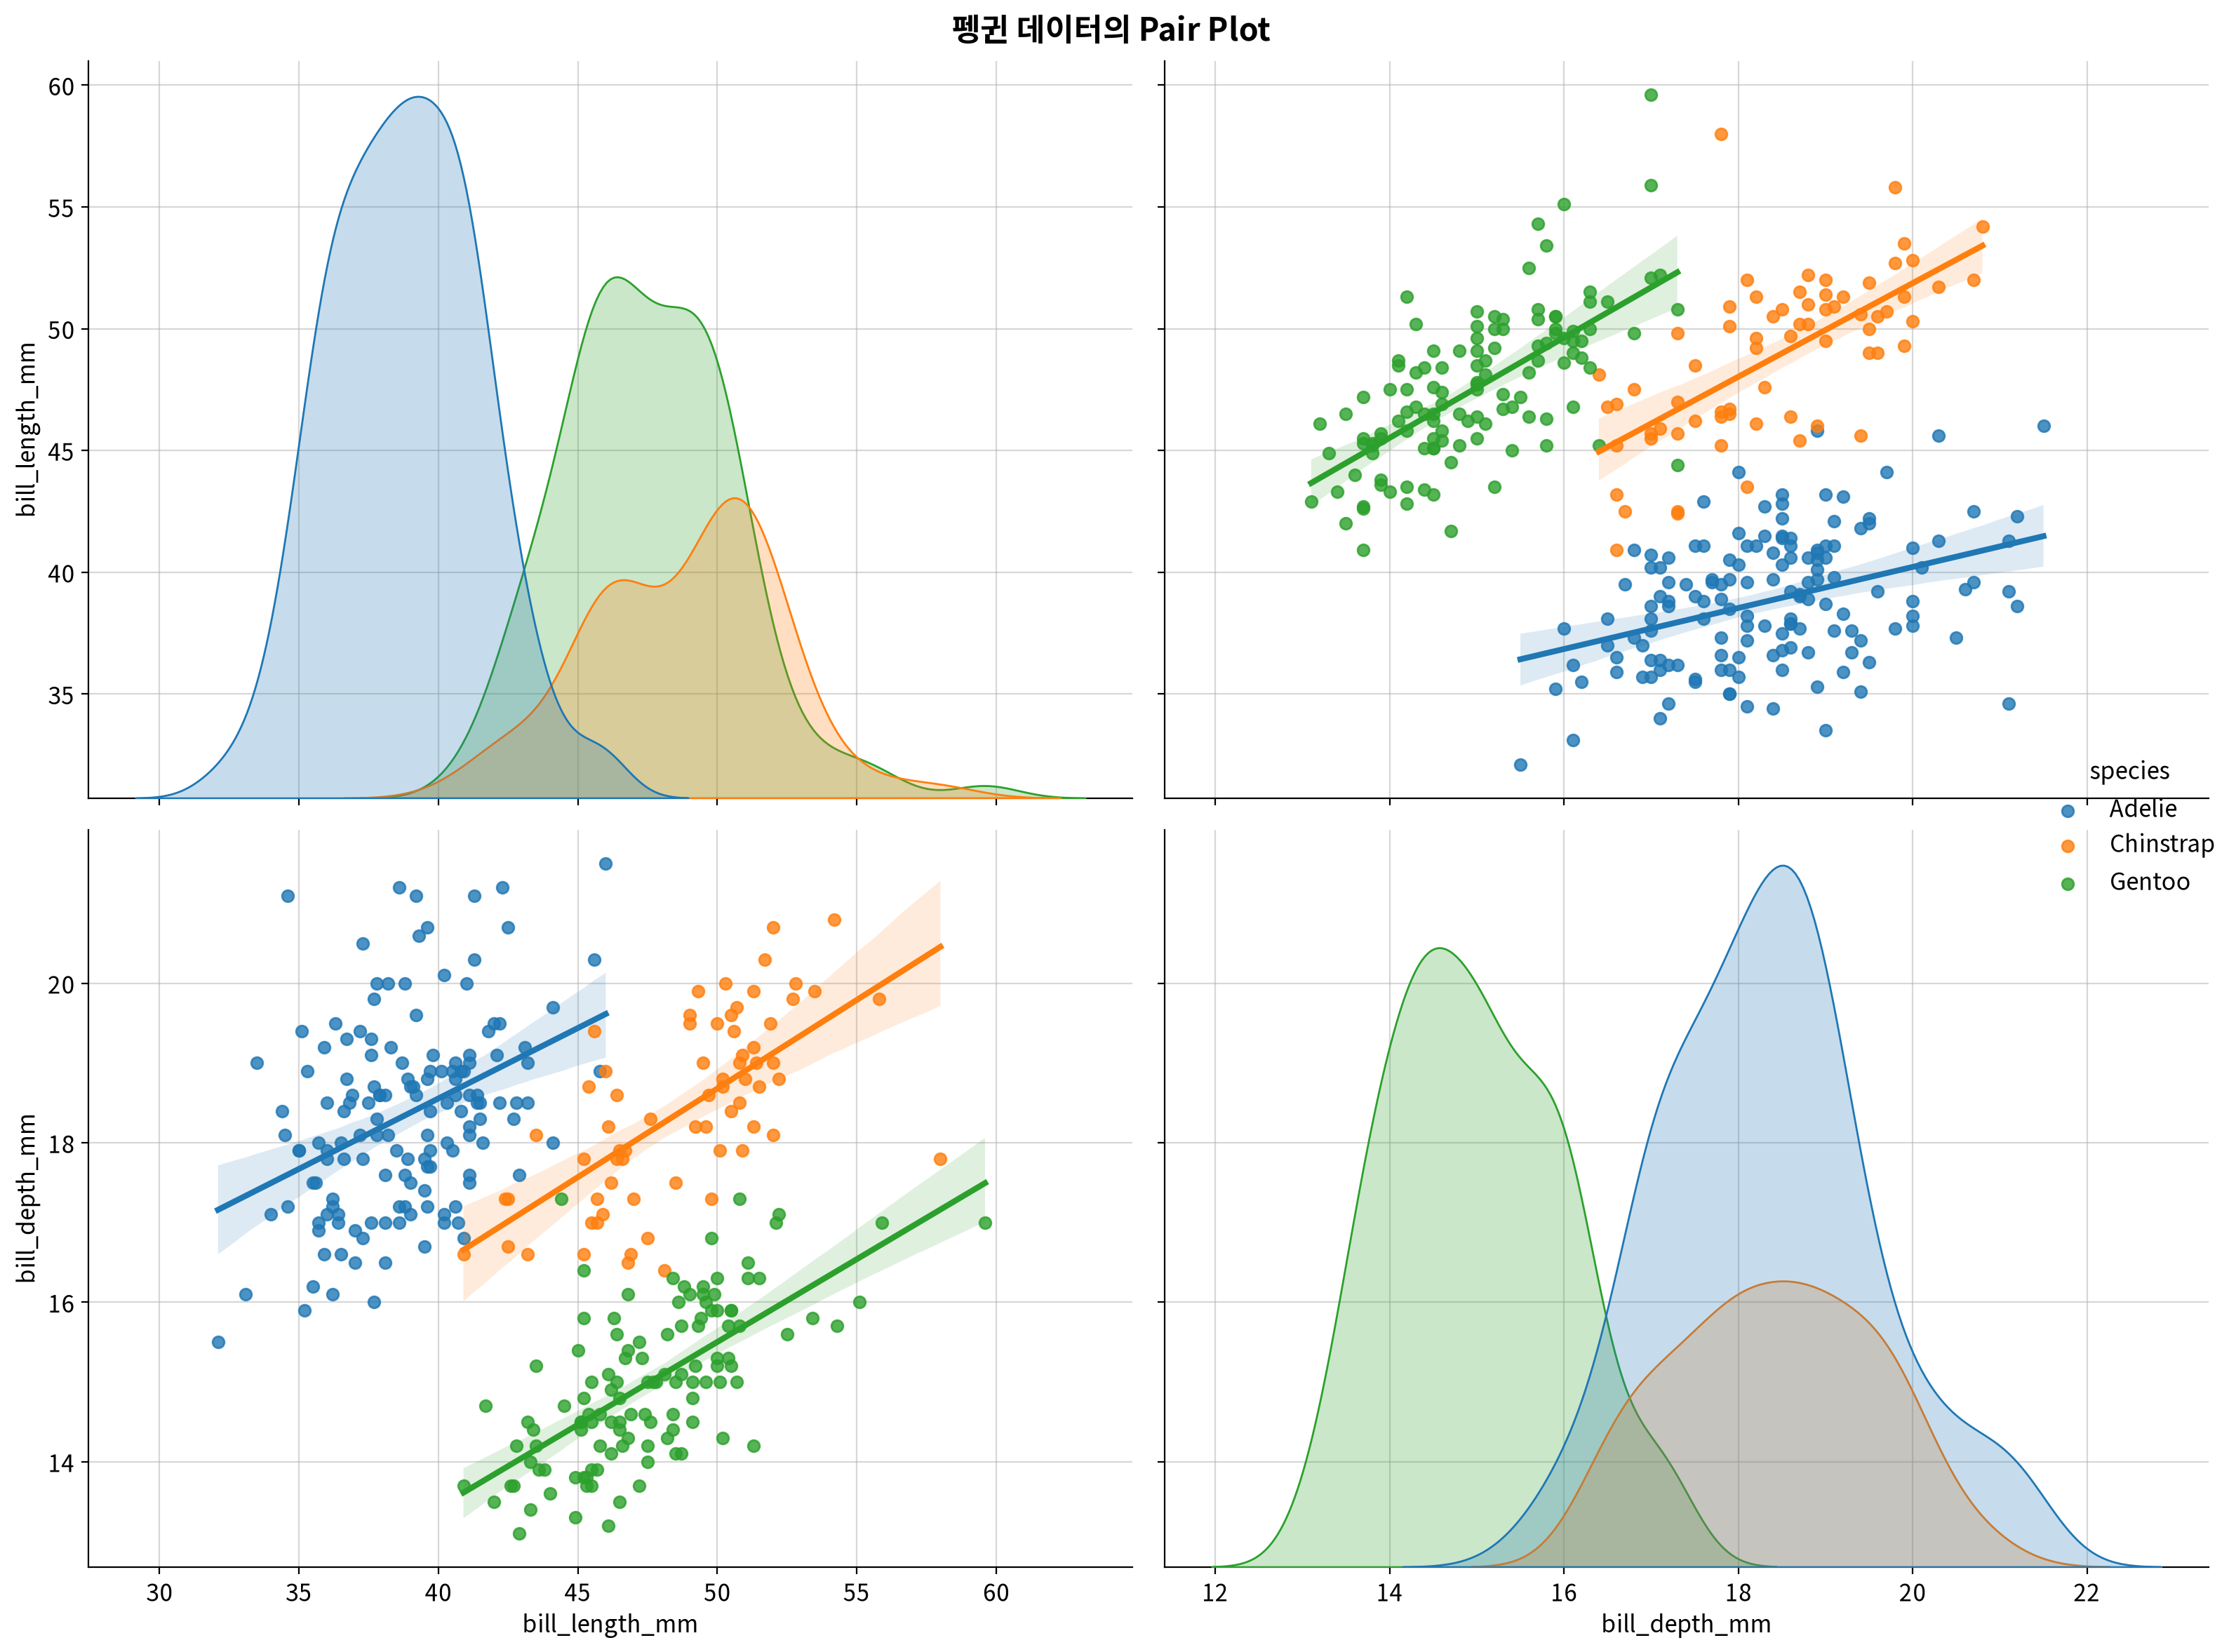

In [6]:
# 1) 그래프 초기화
width  = 1600       # 그래프 가로 px 크기
height = 1200       # 그래프 세로 px 크기
my_dpi = 200        # 그래프 해상도 (DPI)

# 그래프 크기를 inch 단위로 변환
figsize = (width / 100, height / 100)

# 2) Pait Plot 그리기
g = sb.pairplot(origin, hue='species', kind='reg', diag_kind='kde',
            x_vars=["bill_length_mm", "bill_depth_mm"],
            y_vars=["bill_length_mm", "bill_depth_mm"]
)

g.fig.set_dpi(my_dpi)
g.fig.set_figwidth(figsize[0])
g.fig.set_figheight(figsize[1])

# 제목 추가
g.fig.suptitle("펭귄 데이터의 Pair Plot", fontsize=16, fontweight="bold")

# 3) 개별 그래프 설정
for ax in g.axes.flatten():
    ax.set_axisbelow(True)  # 격자를 그래프 뒤로 이동
    ax.grid(True, alpha=0.5)  # 격자 추가

# 4) 출력
my_plot.show()

## #03. 모듈화 기능 확인

### 1. 기본 사용

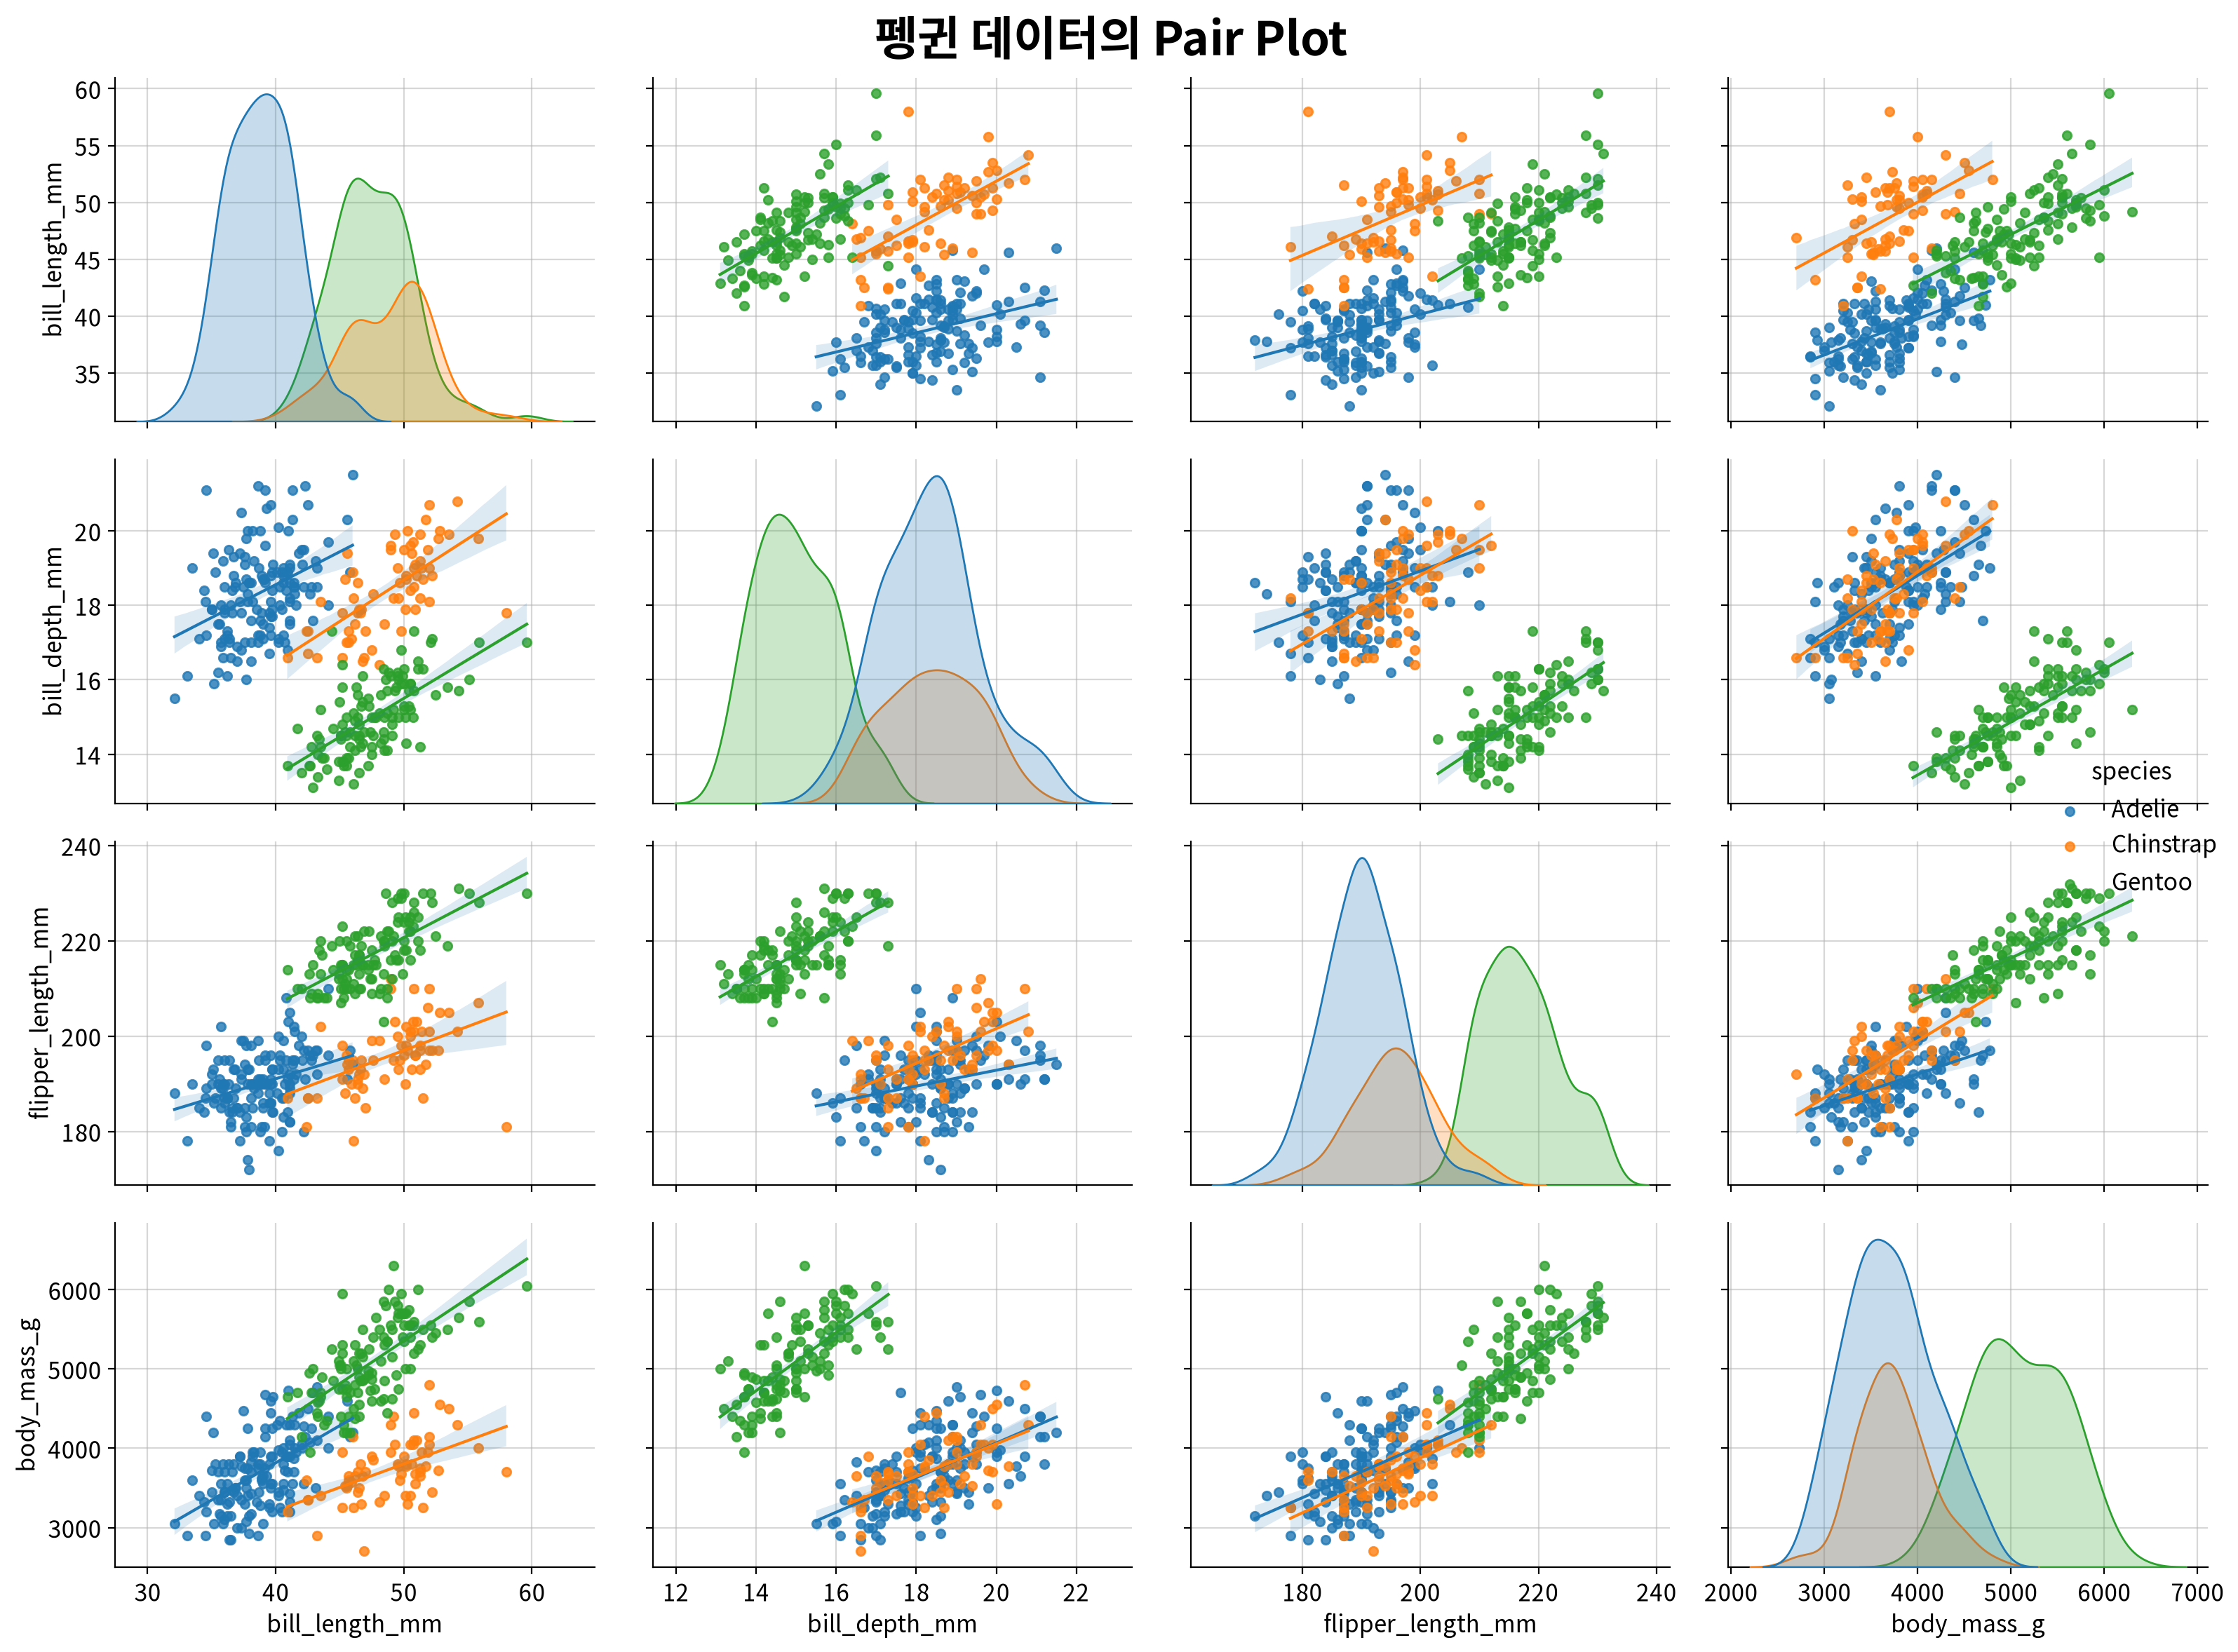

In [7]:
my_plot.pairplot(origin, 
                hue='species',                  # 범주형 컬럼명 지정
                reg=True,                       # 산점도에 회귀선 추가
                diag_kind='kde',                # 대각선에 KDE 플롯 사용
                title="펭귄 데이터의 Pair Plot",  # 그래프 제목
                width=1600, height=1200,        # 그래프 크기
)

### 2. 그래프 모양 설정

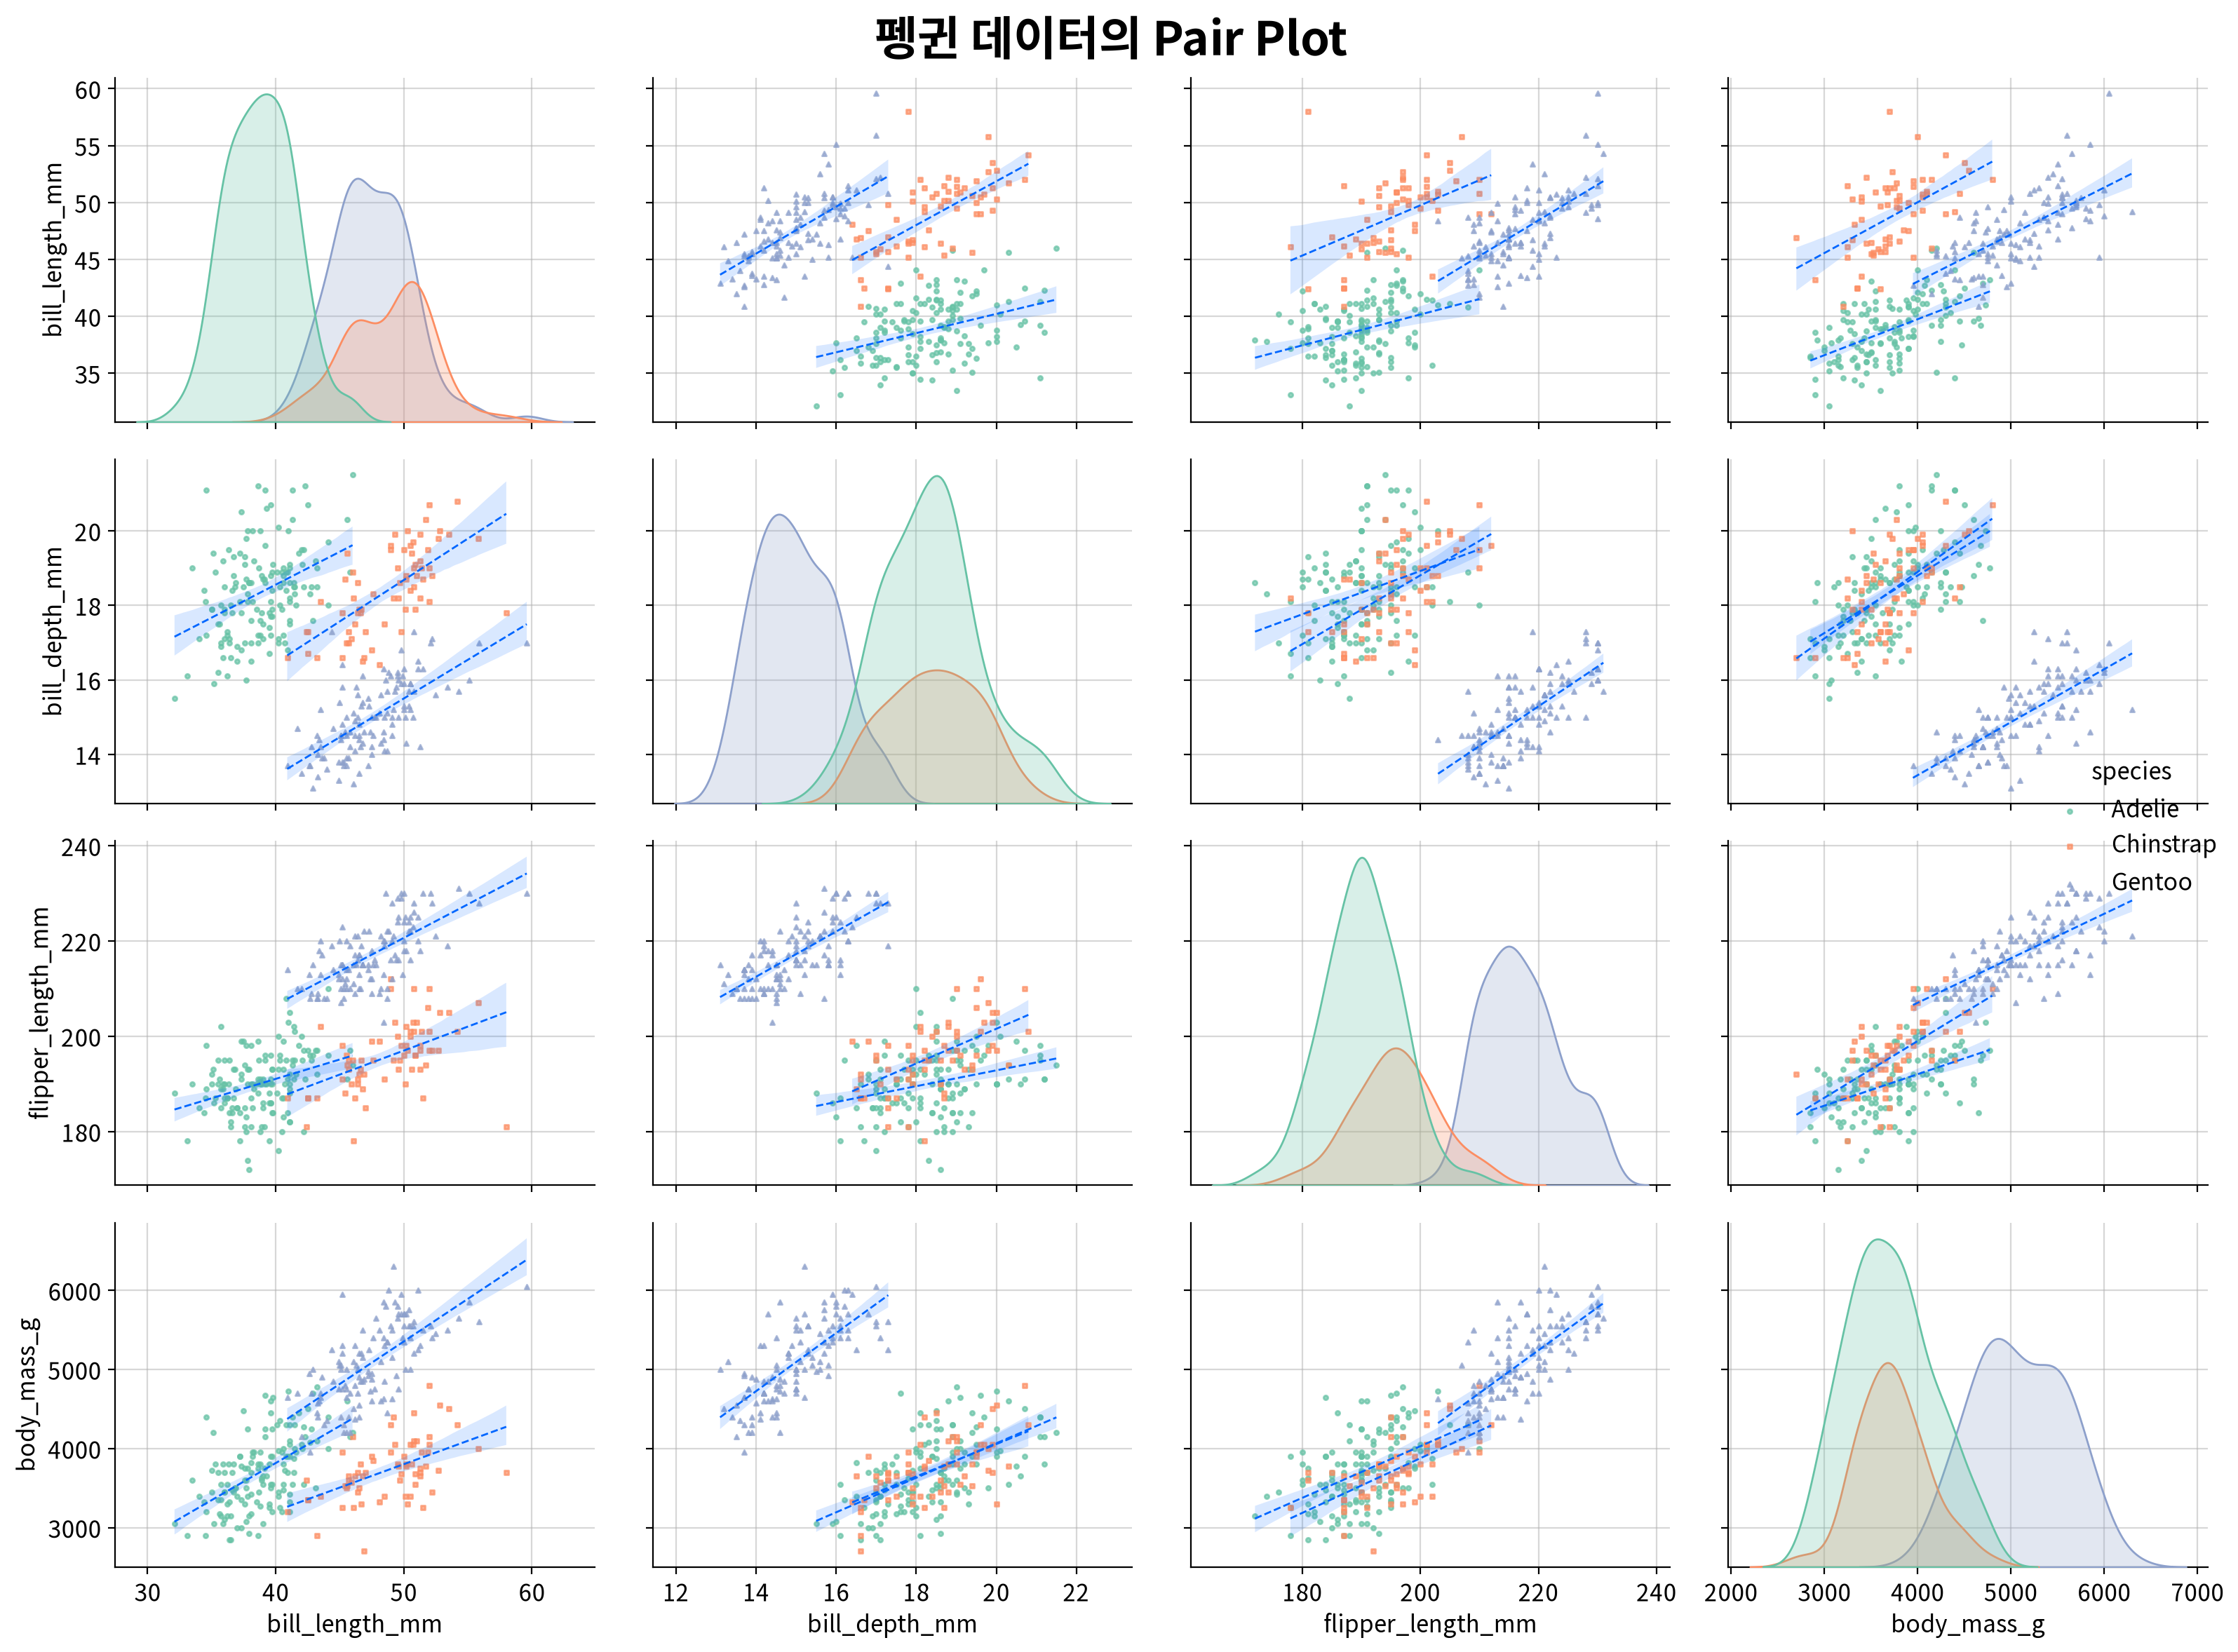

In [8]:
my_plot.pairplot(origin, 
                hue='species',                  # 범주형 컬럼명 지정
                reg=True,                       # 산점도에 회귀선 추가
                diag_kind='kde',                # 대각선에 KDE 플롯 사용
                title="펭귄 데이터의 Pair Plot",  # 그래프 제목
                width=1600, height=1200,        # 그래프 크기
                markers=['o', 's', '^'],        # 종별로 다른 마커 사용
                palette='Set2',                 # 종별로 다른 색상 팔레트 사용
                scatter_size=5,                 # 산점도 마커 크기
                scatter_alpha=0.7,              # 산점도 마커 투명도
                linecolor='#0066ff',            # 회귀선 색상
                linewidth=1,                    # 회귀선 두께
                linestyle='--'                  # 회귀선 스타일
)